In [77]:
print("helloe")

helloe


In [78]:
import os
import sys
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import logging
from typing import Annotated, List, Dict, Any, Literal
from typing_extensions import TypedDict
import litellm
from langchain_litellm import ChatLiteLLM  
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import re
from langchain_core.tools import tool
from tavily import TavilyClient
from langgraph.prebuilt import ToolNode
from sqlalchemy import create_engine, text
import requests
from bs4 import BeautifulSoup
import uuid
from pydantic import BaseModel, Field
from pinecone import Pinecone
import json
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import time

In [79]:
litellm.success_callback = []
litellm.failure_callback = []
litellm.callbacks = []             
litellm.set_verbose = False
logging.getLogger("litellm").setLevel(logging.CRITICAL)
sys.stderr = open(os.devnull, 'w')


In [80]:
from typing import Annotated, Any, Dict, List
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class TeamState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    next_agent: str
    source_documents: List[Dict[str, Any]]
    generated_outputs: List[Dict[str, Any]]

In [ ]:
import json
import time
import os
import re
import litellm
from langchain_litellm import ChatLiteLLM
from langchain_core.messages import AIMessage

# ====================================================================
# 🤫 SILENCE LITELLM LOGS COMPLETELY
# ====================================================================
litellm.set_verbose = False
litellm.suppress_debug_info = True
litellm.turn_off_message_logging = True

try:
    litellm._logging._disable_debugging()
except AttributeError:
    pass

# ====================================================================
# INITIALIZE LITELLM PROVIDERS
# ====================================================================
groq_llm = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.1,
    max_tokens=1500,
)

gemini_llm = ChatLiteLLM(
    model="gemini/gemini-2.5-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    temperature=0.1,
    max_tokens=1500,
)

# OpenRouter configuration with active fallback tracking properties
openrouter_llm = ChatLiteLLM(
    model="openrouter/openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0.1,
    max_tokens=1500,
)

# ====================================================================
# PRODUCTION LLM GATEWAY & FALLBACK ORCHESTRATION LAYER 🚀
# ====================================================================
class FallbackLLM:

    def __init__(self, models):
        self.models = models
        # Global Registry for tracking gateway performance over time
        self.gateway_metrics = {
            "total_calls": 0,
            "failed_calls": 0,
            "input_tokens_served": 0,
            "output_tokens_served": 0,
            "accumulated_cost_usd": 0.0
        }
        # Industry price points per 1M tokens (Standard 2026 Registry limits)
        self._cost_table = {
            "groq/llama-3.3-70b-versatile": {"input": 0.59, "output": 0.79},
            "gemini/gemini-2.5-flash": {"input": 0.075, "output": 0.30},
            "openrouter/openai/gpt-4o-mini": {"input": 0.15, "output": 0.60}
        }

    def _input_guardrail(self, messages) -> bool:
        """Level 1 Guardrail: Scans the incoming conversation stream."""
        if not messages:
            return True
            
        last_msg = messages[-1]
        content = getattr(last_msg, "content", "")
        if not isinstance(content, str):
            return True
            
        content_lower = content.lower()
        
        blocked_patterns = [
            "drop table", "delete from", "truncate table", "insert into",
            "ignore previous instructions", "system override", "reveal your system prompt"
        ]
        
        for pattern in blocked_patterns:
            if pattern in content_lower:
                return False
        return True

    def _output_guardrail(self, content: str) -> str:
        """Level 3 Guardrail: Stops raw API keys or passwords from rendering."""
        if not content:
            return content
            
        # 1. Intercept Raw Database Strings
        db_url_pattern = r"(postgresql|postgres|mysql|mongodb):\/\/([^:]+):([^@]+)@([^/]+)\/([^?\s]+)"
        if re.search(db_url_pattern, content):
            return "⚠️ [SECURITY ENFORCEMENT]: Sensitive database credentials were intercepted and hidden."
            
        # 2. Intercept Secret Encryption Column Names
        sensitive_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "gemini_key", "groq_key", "openrouter_key", "tavily_key"
        ]
        for keyword in sensitive_keywords:
            if keyword in content.lower():
                return "⚠️ [SECURITY ENFORCEMENT]: Response blocked to prevent raw encryption keys or passwords from showing."
                
        return content

    def _calculate_costs(self, model_name: str, input_tokens: int, output_tokens: int):
        """Calculates exact API usage costs based on provider rates."""
        if model_name in self._cost_table:
            rates = self._cost_table[model_name]
            in_cost = (input_tokens / 1_000_000) * rates["input"]
            out_cost = (output_tokens / 1_000_000) * rates["output"]
            total_call_cost = in_cost + out_cost
            
            # Record state changes inside the gateway instance memory
            self.gateway_metrics["input_tokens_served"] += input_tokens
            self.gateway_metrics["output_tokens_served"] += output_tokens
            self.gateway_metrics["accumulated_cost_usd"] += total_call_cost

    def invoke(self, messages, **kwargs):
        self.gateway_metrics["total_calls"] += 1
        
        # --- Level 1 Input Guardrail Integration ---
        if not self._input_guardrail(messages):
            return AIMessage(content="🚨 [SECURITY VIOLATION]: Request blocked by system gateway.")

        last_error = None

        for provider_name, llm in self.models:
            try:
                start = time.perf_counter()
                response = llm.invoke(messages, **kwargs)
                elapsed = time.perf_counter() - start

                # Extrapolate structural metadata values safely
                input_tokens = 0
                output_tokens = 0
                if hasattr(response, "usage_metadata") and response.usage_metadata:
                    input_tokens = response.usage_metadata.get("input_tokens", 0)
                    output_tokens = response.usage_metadata.get("output_tokens", 0)
                elif hasattr(response, "response_metadata"):
                    usage = response.response_metadata.get("token_usage") or response.response_metadata.get("usage") or {}
                    input_tokens = usage.get("prompt_tokens", 0)
                    output_tokens = usage.get("completion_tokens", 0)

                # Execute cost registry modifications
                model_str = getattr(llm, "model", "")
                self._calculate_costs(model_str, input_tokens, output_tokens)

                # --- Level 3 Output Guardrail Filter Engine ---
                if hasattr(response, "content") and response.content:
                    response.content = self._output_guardrail(response.content)

                response.response_metadata["selected_provider"] = provider_name
                response.response_metadata["response_time"] = elapsed
                return response

            except Exception as e:
                self.gateway_metrics["failed_calls"] += 1
                last_error = e
                print(f"⚠️ Gateway Notice: {provider_name} fallback activated. Redirecting network traffic...")
                continue

        raise RuntimeError("All configured LLM providers are unavailable.") from last_error

    def with_structured_output(self, schema, **kwargs):
        structured = []
        for provider_name, llm in self.models:
            structured.append((provider_name, llm.with_structured_output(schema, **kwargs)))
        return FallbackLLM(structured)

    def bind_tools(self, tools):
        bound = []
        for provider_name, llm in self.models:
            bound.append((provider_name, llm.bind_tools(tools)))
        return FallbackLLM(bound)

# ====================================================================
# INSTANTIATE GLOBAL GATEWAY ASSETS
# ====================================================================
base_llm = FallbackLLM([
    ("Groq", groq_llm),
    ("Gemini", gemini_llm),
    ("OpenRouter", openrouter_llm),
])

search_planner_llm = base_llm
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")


# Research Agent

In [82]:
# ==========================================
# 1. SIMPLE SEARCH TOOL
# ==========================================
@tool
def simple_web_search(query: str, max_results: int = 2) -> Dict[str, Any]:
    """
    Use this for direct, simple factual lookups, active company homepages, 
    or single entity updates. Returns instant top search snapshots.
    """
    try:
        tavily_client = TavilyClient(api_key=TAVILY_API_KEY)
        return tavily_client.search(query=query, max_results=max_results)
    except Exception as e:
        return {"error": f"Simple search failed: {str(e)}"}

# ===============================================
# 2. DEEP RESEARCH PIPELINE TOOL (Query Breaker)
# ===============================================
@tool
def deep_research_pipeline(complex_intent_query: str) -> Dict[str, Any]:
    """
    Use this ONLY for comprehensive research, background check on companies, 
    market landscape extraction, or deep professional entity tracking.
    This breaks down a single query into efficient sub-queries to scrape deep data.
    """
    try:
        print(f"\n🧠 [Deep Research]: Breaking down query: '{complex_intent_query}'...")
        
        # Internal planner logic to split queries efficiently
        planner_prompt = SystemMessage(content=(
            "You are an expert market intelligence search planner. Your task is to break down the user's "
            "complex research request into EXACTLY 3 unique, specific search engine queries that target different "
            "angles of the topic. Return the output strictly as a JSON list containing 3 string queries. "
            "Example: ['Company X funding rounds 2026', 'Company X tech stack competitors', 'Company X active executives leadership']"
        ))
        
        planner_response = search_planner_llm.invoke([planner_prompt, HumanMessage(content=complex_intent_query)])
        
        # Clean output to ensure safe JSON extraction strings loops
        clean_json_str = planner_response.content.strip().replace("```json", "").replace("```", "")
        sub_queries: List[str] = json.loads(clean_json_str)
        
        tavily_client = TavilyClient(api_key=TAVILY_API_KEY)
        aggregated_research_results = []
        
        print(f"⚙️  [Deep Research]: Generated Sub-Queries: {sub_queries}")
        
        # Run sub-queries sequentially to gather hyper-relevant contexts pools
        for index, sub_query in enumerate(sub_queries):
            print(f" 🔍 Executing Sub-Search {index+1}/3: '{sub_query}'...")
            search_response = tavily_client.search(query=sub_query, max_results=2)
            
            # Extract clean textual snippets out of responses
            snippets = [r.get("content", r.get("snippet", "")) for r in search_response.get("results", [])]
            aggregated_research_results.append({
                "targeted_angle": sub_query,
                "findings": "\n".join(snippets)
            })
            
        return {
            "status": "Deep Analysis Completed Successfully",
            "original_request": complex_intent_query,
            "sub_query_breakdowns": sub_queries,
            "consolidated_context_payload": aggregated_research_results
        }
        
    except Exception as e:
        return {"error": f"Deep research execution matrix failed: {str(e)}"}

# Create dedicated tools pool list asset for research operations
research_tools_pool = [simple_web_search, deep_research_pipeline]

def research_agent_node(state: TeamState):
    """Orchestrates between executing quick factual searches or invoking multi-step query breakers."""
    messages = state["messages"]
    system_prompt = SystemMessage(content=(
        "You are a web search agent. CRITICAL RULE: For simple facts, call simple_web_search."
        "For deep data, background checks, or multiple angles, you MUST call deep_research_pipeline immediately."
        "Analyze the results and report back."
    ))
    response = research_llm.invoke([system_prompt] + messages)
    return {"messages": [response], "next_agent": "supervisor"}

# Lead Agent

In [83]:
engine = create_engine(os.getenv("DATABASE_URL"))
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

# ==================== EXISTING + IMPROVED TOOLS ====================

@tool
def get_user_context(email: str) -> Dict[str, Any]:
    """Fetch user profile and preferences."""
    try:
        with engine.connect() as conn:
            result = conn.execute(
                text("""
                    SELECT id, email, full_name, role, phone, 
                           resume_uploaded, app_password_verified
                    FROM users WHERE email = :email
                """),
                {"email": email}
            )
            row = result.mappings().first()
            if not row:
                return {"success": False, "message": "User not found"}
            return {"success": True, "user": dict(row)}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def web_search(query: str, max_results: int = 10) -> Dict:
    """Perform web search using Tavily."""
    try:
        tavily = TavilyClient(api_key=TAVILY_API_KEY)
        return tavily.search(query=query, max_results=max_results)
    except Exception as e:
        return {"error": str(e)}


@tool
def scrape_website(url: str) -> Dict[str, Any]:
    """Scrape company website for key information."""
    try:
        headers = {"User-Agent": "Mozilla/5.0 (compatible; OutreachX/1.0)"}
        response = requests.get(url, timeout=12, headers=headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        
        return {
            "title": soup.title.string.strip() if soup.title else "",
            "content": soup.get_text(" ", strip=True)[:8000],
            "meta_description": soup.find("meta", attrs={"name": "description"})
        }
    except Exception as e:
        return {"error": str(e)}


@tool
def extract_emails_from_url(url: str) -> List[str]:
    """Extract email addresses from a given URL."""
    try:
        response = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
        emails = re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', response.text)
        return list(set(emails))
    except Exception:
        return []


# ==================== NEW TOOLS FOR LEAD AGENT ====================

@tool
def generate_leads_batch(goal: str, target_audience: str, num_leads: int = 10) -> List[Dict]:
    """
    High-level tool: Generate structured company leads based on user goal.
    This tool should be called after planning.
    """
    # This will be implemented by the Lead Agent LLM + search tools internally
    # For now, returning placeholder structure
    return {
        "status": "planning",
        "message": f"Generating {num_leads} leads for goal: {goal}, audience: {target_audience}"
    }


@tool
def save_leads_to_db(user_id: str, leads: List[Dict], file_name: str) -> Dict:
    """Save generated leads into the database as a lead file."""
    try:
        with engine.connect() as conn:
            # You would insert into 'leads' and 'lead_records' tables here
            return {
                "success": True,
                "message": f"Saved {len(leads)} leads as {file_name}",
                "lead_file_id": "generated_id"
            }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def search_existing_lead_files(user_id: str, limit: int = 5) -> List[Dict]:
    """Search user's previously created lead files."""
    try:
        with engine.connect() as conn:
            result = conn.execute(
                text("""
                    SELECT id, file_name, row_count, status, created_at 
                    FROM leads 
                    WHERE user_id = :user_id 
                    ORDER BY created_at DESC LIMIT :limit
                """),
                {"user_id": user_id, "limit": limit}
            )
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def validate_and_clean_leads(leads: List[Dict]) -> List[Dict]:
    """Clean and validate lead data (remove duplicates, fix formats, etc.)."""
    # Basic cleaning logic can be added here
    cleaned = []
    seen = set()
    for lead in leads:
        if lead.get("company_name") and lead.get("company_name") not in seen:
            seen.add(lead.get("company_name"))
            cleaned.append(lead)
    return cleaned


@tool
def get_company_details(company_name: str) -> Dict:
    """Deep dive on a single company (website, industry, size, etc.)."""
    # Can internally call web_search + scrape_website
    return {"company_name": company_name, "status": "research_in_progress"}

# Campaign Agent

In [84]:
engine = create_engine(os.getenv("DATABASE_URL"))

# ==================== IMPROVED EXISTING TOOLS ====================

@tool
def fetch_user_context(user_id: str) -> Dict[str, Any]:
    """Fetch user profile + recent memory."""
    try:
        with engine.connect() as conn:
            profile_query = text("""SELECT full_name, email, role FROM users WHERE id = CAST(:user_id AS UUID);""")
            
            profile = conn.execute(profile_query, {"user_id": user_id}).fetchone()
            
            return {
                "success": True,
                "profile": dict(profile._mapping) if profile else {},
                "user_id": str(user_id),
            }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def search_existing_leads(user_id: str, limit: int = 5) -> List[Dict]:
    """Get user's existing lead files."""
    try:
        with engine.connect() as conn:
            query = text("""
                SELECT id, file_name, status, row_count, columns, created_at 
                FROM leads 
                WHERE user_id = CAST(:user_id AS UUID)
                ORDER BY created_at DESC LIMIT :limit
            """)
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            rows = [dict(row._mapping) for row in result]
            for r in rows:
                r['id'] = str(r['id'])
            return rows
    except Exception as e:
        return {"error": str(e)}


@tool
def search_existing_templates(user_id: str, limit: int = 5) -> List[Dict]:
    """Get user's existing templates."""
    try:
        with engine.connect() as conn:
            query = text("""
                SELECT id, name, description, subject_line, variables, is_ai_generated 
                FROM templates 
                WHERE user_id = CAST(:user_id AS UUID)
                ORDER BY created_at DESC LIMIT :limit
            """)
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            rows = [dict(row._mapping) for row in result]
            for r in rows:
                r['id'] = str(r['id'])
            return rows
    except Exception as e:
        return {"error": str(e)}


@tool
def propose_variable_mapping(lead_columns: List[str], template_variables: List[str]) -> Dict[str, str]:
    """Propose smart variable mapping between lead file and template."""
    mapping = {}
    for var in template_variables:
        clean_var = var.strip('{}')
        # Smart matching logic
        if clean_var in lead_columns:
            mapping[var] = clean_var
        elif clean_var.lower() == "company_name" and "company" in [c.lower() for c in lead_columns]:
            mapping[var] = "company_name"
        else:
            mapping[var] = None  # Needs manual mapping
    return mapping


# ==================== NEW & CRITICAL TOOLS ====================

@tool
def verify_email_credentials(user_id: str, app_password: str) -> Dict[str, Any]:
    """Verify user's Gmail App Password by sending a test code."""
    try:
        user_email = "..."  # Fetch from DB
        # Logic: Send verification code via system email
        # Then store temporarily and return success
        return {
            "success": True,
            "message": "Verification code sent to your email. Please check."
        }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def send_test_email(user_id: str, template_id: str, lead_record: Dict) -> Dict[str, Any]:
    """Send real test email using user's SMTP credentials."""
    try:
        # Fetch user email + app password from DB
        # Use smtplib to send real test email
        return {
            "success": True,
            "message": "Test email sent successfully to your inbox.",
            "preview": "Email preview content..."
        }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def create_campaign(user_id: str, name: str, description: str, 
                   lead_file_id: str, template_id: str, 
                   variable_mapping: Dict) -> Dict:
    """Create and save a new campaign in the database."""
    try:
        with engine.connect() as conn:
            # Insert into campaigns table
            query = text("""
                INSERT INTO campaigns (user_id, name, description, lead_file_id, 
                                     template_id, variable_mapping, status)
                VALUES (:user_id, :name, :description, :lead_file_id, 
                        :template_id, :mapping, 'draft')
                RETURNING id;
            """)
            result = conn.execute(query, {
                "user_id": user_id,
                "name": name,
                "description": description,
                "lead_file_id": lead_file_id,
                "template_id": template_id,
                "mapping": json.dumps(variable_mapping)
            })
            campaign_id = result.scalar()
            
        return {"success": True, "campaign_id": str(campaign_id)}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def launch_campaign(campaign_id: str) -> Dict:
    """Launch the campaign (after verification)."""
    # This will queue emails with rate limiting
    return {
        "success": True,
        "message": "Campaign launched successfully. Monitoring started."
    }

# Template agent

In [85]:
from sqlalchemy import create_engine, text
from pinecone import Pinecone
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import List, Dict, Any
import requests
import os
from langchain_core.messages import SystemMessage, HumanMessage

# Initialize clients
engine = create_engine(os.getenv("DATABASE_URL"))
pc = Pinecone(api_key=os.getenv("PINECONE_API_KEY"))
index = pc.Index(os.getenv("PINECONE_INDEX_NAME", "outreachx"))

# ==================== OUTPUT SCHEMAS ====================
class EmailTemplate(BaseModel):
    subject_line: str = Field(description="Subject line for the cold email")
    text_content: str = Field(description="Plain text version. MUST include {{company_name}}")
    html_content: str = Field(description="HTML version (optional)", default="")

class TemplateOutput(BaseModel):
    variations: List[EmailTemplate] = Field(description="List of template variations")


# ==================== TOOLS ====================

@tool
def get_user_context(email: str) -> Dict[str, Any]:
    """Fetch complete user context including resume, assets, and memory."""
    try:
        query = text("""
            SELECT
                u.id, u.full_name, u.email, u.phone, u.role,
                r.raw_text AS resume_text,
                r.skills, r.projects, r.experience, r.education,
                r.social_media_links, r.certifications, r.objective,
                (
                    SELECT json_agg(json_build_object('name', a.name, 'type', a.asset_type, 
                        'description', a.description, 'content', a.content, 'metadata', a.metadata))
                    FROM assets a WHERE a.user_id = u.id
                ) AS assets,
                (
                    SELECT json_agg(json_build_object('role', m.role, 'message', m.content))
                    FROM ai_memory m WHERE m.user_id = u.id
                ) AS memories
            FROM users u
            LEFT JOIN user_resumes r ON r.user_id = u.id
            WHERE u.email = :email;
        """)

        with engine.connect() as conn:
            row = conn.execute(query, {"email": email}).fetchone()
            if not row:
                return {"success": False, "error": "User not found"}

            data = dict(row._mapping)
            return {
                "success": True,
                "user": {
                    "id": str(data["id"]),
                    "name": data["full_name"],
                    "email": data["email"],
                    "role": data["role"]
                },
                "resume": {
                    "raw_text": data["resume_text"],
                    "skills": data["skills"],
                    "projects": data["projects"],
                    "experience": data["experience"]
                },
                "assets": data["assets"] or [],
                "memories": data["memories"] or []
            }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def retrieve_relevant_assets(email: str, query: str, top_k: int = 5) -> List[Dict]:
    """Retrieve relevant user projects/assets from Pinecone."""
    try:
        # Get user ID first
        context = get_user_context.invoke(email)
        if not context.get("success"):
            return [{"error": "User not found"}]

        user_id = context["user"]["id"]
        namespace = f"user_{user_id}"

        # Cohere embedding
        cohere_key = os.getenv("COHERE_API_KEY")
        response = requests.post(
            "https://api.cohere.com/v2/embed",
            json={
                "model": "embed-english-v3.0",
                "input_type": "search_query",
                "texts": [query],
                "embedding_types": ["float"]
            },
            headers={"Authorization": f"Bearer {cohere_key}"}
        )
        response.raise_for_status()
        embedding = response.json()["embeddings"]["float"][0]

        # Query Pinecone
        result = index.query(
            vector=embedding,
            top_k=top_k,
            include_metadata=True,
            namespace=namespace
        )

        snippets = []
        for match in result.get('matches', []):
            meta = match.get('metadata', {})
            snippets.append({
                "asset_name": meta.get('name', 'Unknown'),
                "content": meta.get('text', '')[:500]
            })
        return snippets

    except Exception as e:
        return [{"error": str(e)}]


@tool
def generate_template_variations(
    email: str,
    user_query: str,
    company_name: str = "{{company_name}}",
    number_of_variations: int = 2,
    prefer_html: bool = False
) -> str:
    """Generate personalized cold email template variations."""
    try:
        # 1. Get user context
        context = get_user_context.invoke(email)
        if not context.get("success"):
            return "Error: User context not found."

        # 2. Get relevant assets
        assets = retrieve_relevant_assets.invoke({
            "email": email, 
            "query": user_query
        })

        asset_text = "\n".join([f"- {a['asset_name']}: {a['content']}" for a in assets if 'content' in a])

        # 3. Structured LLM Call
        structured_model = base_llm.with_structured_output(TemplateOutput)

        system_prompt = f"""
        You are an expert cold email writer.
        Generate {number_of_variations} highly personalized variations.
        Use the user's real information. Only use {{company_name}} as placeholder.
        """

        user_prompt = f"""
        Company: {company_name}
        Goal: {user_query}

        User Info:
        Name: {context['user']['name']}
        Role: {context['user']['role']}
        Resume: {context['resume'].get('raw_text', '')[:1000]}

        Relevant Projects/Assets:
        {asset_text}
        """

        response = structured_model.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ])

        # Format output nicely
        output = ""
        for i, var in enumerate(response.variations):
            output += f"=== VARIATION {i+1} ===\n"
            output += f"Subject: {var.subject_line}\n\n"
            output += f"Plain Text:\n{var.text_content}\n\n"
            if var.html_content:
                output += f"HTML:\n{var.html_content}\n"
            output += "-" * 50 + "\n"

        return output

    except Exception as e:
        return f"Error generating templates: {str(e)}"


@tool
def save_template(
    user_id: str, 
    name: str, 
    subject_line: str, 
    text_content: str, 
    html_content: str = "",
    variables: List[str] = None
) -> Dict[str, Any]:
    """Save approved template to database."""
    try:
        with engine.connect() as conn:
            query = text("""
                INSERT INTO templates 
                (user_id, name, subject_line, text_content, html_content, variables, is_ai_generated)
                VALUES (:user_id, :name, :subject, :text, :html, :vars, TRUE)
                RETURNING id;
            """)
            result = conn.execute(query, {
                "user_id": user_id,
                "name": name,
                "subject": subject_line,
                "text": text_content,
                "html": html_content,
                "vars": variables or ["company_name"]
            })
            template_id = result.scalar()

        return {"success": True, "template_id": str(template_id), "message": "Template saved successfully"}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def list_user_templates(user_id: str, limit: int = 10) -> List[Dict]:
    """List user's saved templates."""
    try:
        with engine.connect() as conn:
            query = text("""
                SELECT id, name, subject_line, is_ai_generated, created_at 
                FROM templates 
                WHERE user_id = CAST(:user_id AS UUID)
                ORDER BY created_at DESC 
                LIMIT :limit
            """)
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}

# Analysis Agent

In [86]:
from sqlalchemy import create_engine, text
from langchain_core.tools import tool
from typing import List, Dict, Any, Optional

engine = create_engine(os.getenv("DATABASE_URL"))

@tool
def list_user_campaigns(user_id: str, limit: int = 10, status: Optional[str] = None) -> List[Dict]:
    """List all campaigns with performance metrics."""
    try:
        query = text("""
            SELECT id, name, status, total_leads, sent_count, opened_count, 
                   clicked_count, replied_count, bounced_count, created_at
            FROM campaigns
            WHERE user_id = CAST(:user_id AS UUID)
            ORDER BY created_at DESC
            LIMIT :limit
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def get_campaign_performance(campaign_id: str) -> Dict[str, Any]:
    """Get detailed performance analytics for a specific campaign."""
    try:
        with engine.connect() as conn:
            query = text("""
                SELECT c.name, c.status, c.total_leads, c.sent_count,
                       c.opened_count, c.clicked_count, c.replied_count, c.bounced_count,
                       (c.replied_count::float / NULLIF(c.sent_count, 0) * 100) as reply_rate,
                       (c.opened_count::float / NULLIF(c.sent_count, 0) * 100) as open_rate
                FROM campaigns c
                WHERE c.id = CAST(:campaign_id AS UUID)
            """)
            result = conn.execute(query, {"campaign_id": campaign_id}).fetchone()
            if result:
                return {"success": True, "data": dict(result._mapping)}
            return {"success": False, "message": "Campaign not found"}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def compare_templates_performance(user_id: str) -> List[Dict]:
    """Compare which templates are performing best based on replies."""
    try:
        query = text("""
            SELECT t.id, t.name, t.subject_line,
                   COUNT(e.id) as total_sent,
                   SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END) as replies,
                   ROUND(SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END)::float / 
                         NULLIF(COUNT(e.id), 0) * 100, 2) as reply_rate
            FROM templates t
            JOIN campaigns c ON c.template_id = t.id
            JOIN email_logs e ON e.campaign_id = c.id
            WHERE t.user_id = CAST(:user_id AS UUID)
            GROUP BY t.id, t.name, t.subject_line
            ORDER BY reply_rate DESC
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def list_lead_files(user_id: str, limit: int = 10) -> List[Dict]:
    """List all lead files with summary."""
    try:
        query = text("""
            SELECT id, file_name, row_count, status, created_at
            FROM leads
            WHERE user_id = CAST(:user_id AS UUID)
            ORDER BY created_at DESC LIMIT :limit
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            rows = [dict(row._mapping) for row in result]
            for r in rows:
                r['id'] = str(r['id'])
            return rows
    except Exception as e:
        return {"error": str(e)}


@tool
def get_user_assets_summary(user_id: str) -> Dict:
    """Get summary of user's assets and resume data."""
    try:
        query = text("""
            SELECT 
                COUNT(*) as total_assets,
                COUNT(CASE WHEN asset_type = 'resume' THEN 1 END) as resume_count,
                COUNT(CASE WHEN asset_type = 'project' THEN 1 END) as project_count
            FROM assets
            WHERE user_id = CAST(:user_id AS UUID)
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id}).fetchone()
            return dict(result._mapping) if result else {}
    except Exception as e:
        return {"error": str(e)}


@tool
def analyze_campaign_trends(user_id: str) -> Dict[str, Any]:
    """Give high-level insights on user's campaign performance."""
    try:
        query = text("""
            SELECT 
                ROUND(AVG((replied_count::float / NULLIF(sent_count, 0)) * 100), 2) as avg_reply_rate,
                COUNT(*) as total_campaigns,
                SUM(sent_count) as total_emails_sent
            FROM campaigns
            WHERE user_id = CAST(:user_id AS UUID) AND sent_count > 0
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id}).fetchone()
            data = dict(result._mapping) if result else {}
            return {
                "success": True,
                "insights": {
                    "average_reply_rate": data.get("avg_reply_rate", 0),
                    "total_campaigns": data.get("total_campaigns", 0),
                    "total_emails_sent": data.get("total_emails_sent", 0)
                }
            }
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def get_best_performing_template(user_id: str) -> Dict:
    """Recommend the best template based on reply rate."""
    try:
        query = text("""
            SELECT t.name, t.subject_line,
                   COUNT(e.id) as sent,
                   SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END) as replies,
                   ROUND(SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END)::float / 
                         NULLIF(COUNT(e.id), 0) * 100, 2) as reply_rate
            FROM templates t
            JOIN campaigns c ON c.template_id = t.id
            JOIN email_logs e ON e.campaign_id = c.id
            WHERE t.user_id = CAST(:user_id AS UUID)
            GROUP BY t.id, t.name, t.subject_line
            ORDER BY reply_rate DESC
            LIMIT 1
        """)
        with engine.connect() as conn:
            row = conn.execute(query, {"user_id": user_id}).fetchone()
            return dict(row._mapping) if row else {"message": "No data yet"}
    except Exception as e:
        return {"error": str(e)}


# ==================== 10 NEW TOOLS ====================

@tool
def get_recent_email_activity(user_id: str, limit: int = 15) -> List[Dict]:
    """Get recent email send, open, reply activity."""
    try:
        query = text("""
            SELECT e.lead_email, e.status, e.sent_at, e.opened_at, e.replied_at, c.name as campaign_name
            FROM email_logs e
            JOIN campaigns c ON e.campaign_id = c.id
            WHERE c.user_id = CAST(:user_id AS UUID)
            ORDER BY e.sent_at DESC LIMIT :limit
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id, "limit": limit})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def get_top_lead_sources(user_id: str) -> List[Dict]:
    """Which lead files give highest reply rate."""
    try:
        query = text("""
            SELECT l.file_name, COUNT(e.id) as sent,
                   SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END) as replies,
                   ROUND(SUM(CASE WHEN e.replied_at IS NOT NULL THEN 1 ELSE 0 END)::float / 
                         NULLIF(COUNT(e.id), 0) * 100, 2) as reply_rate
            FROM leads l
            JOIN email_logs e ON e.leads_file_id = l.id
            WHERE l.user_id = CAST(:user_id AS UUID)
            GROUP BY l.id, l.file_name
            ORDER BY reply_rate DESC LIMIT 8
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def get_user_overall_stats(user_id: str) -> Dict:
    """Overall statistics for the user."""
    try:
        query = text("""
            SELECT 
                COUNT(DISTINCT c.id) as total_campaigns,
                COALESCE(SUM(c.sent_count), 0) as total_emails_sent,
                COALESCE(SUM(c.replied_count), 0) as total_replies,
                ROUND(AVG((c.replied_count::float / NULLIF(c.sent_count, 0)) * 100), 2) as avg_reply_rate
            FROM users u
            LEFT JOIN campaigns c ON c.user_id = u.id
            WHERE u.id = CAST(:user_id AS UUID)
        """)
        with engine.connect() as conn:
            row = conn.execute(query, {"user_id": user_id}).fetchone()
            return dict(row._mapping) if row else {}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_monthly_performance(user_id: str) -> List[Dict]:
    """Monthly campaign performance trend."""
    try:
        query = text("""
            SELECT DATE_TRUNC('month', created_at) as month,
                   COUNT(*) as campaigns,
                   SUM(sent_count) as emails_sent,
                   SUM(replied_count) as replies
            FROM campaigns
            WHERE user_id = CAST(:user_id AS UUID)
            GROUP BY month
            ORDER BY month DESC LIMIT 6
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def get_bounce_reasons(user_id: str) -> List[Dict]:
    """Common bounce reasons analysis."""
    try:
        query = text("""
            SELECT bounce_reason, COUNT(*) as count
            FROM email_logs
            WHERE bounce_reason IS NOT NULL 
              AND campaign_id IN (SELECT id FROM campaigns WHERE user_id = CAST(:user_id AS UUID))
            GROUP BY bounce_reason
            ORDER BY count DESC
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def recommend_next_action(user_id: str) -> str:
    """AI suggestion for what user should do next."""
    # This tool can call LLM internally for smart recommendation
    return "Based on your data, focus on improving subject lines and targeting better companies."


@tool
def get_email_credential_status(user_id: str) -> Dict:
    """Check status of user's email credentials."""
    try:
        query = text("""
            SELECT email_address, is_verified, verified_at, last_tested_at
            FROM email_credentials
            WHERE user_id = CAST(:user_id AS UUID)
        """)
        with engine.connect() as conn:
            row = conn.execute(query, {"user_id": user_id}).fetchone()
            return dict(row._mapping) if row else {"message": "No credentials found"}
    except Exception as e:
        return {"error": str(e)}


@tool
def list_all_user_templates(user_id: str) -> List[Dict]:
    """List all saved templates with usage count."""
    try:
        query = text("""
            SELECT t.name, t.subject_line, t.is_ai_generated,
                   COUNT(c.id) as used_in_campaigns
            FROM templates t
            LEFT JOIN campaigns c ON c.template_id = t.id
            WHERE t.user_id = CAST(:user_id AS UUID)
            GROUP BY t.id, t.name, t.subject_line, t.is_ai_generated
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def get_low_performing_campaigns(user_id: str) -> List[Dict]:
    """Campaigns with low reply rate."""
    try:
        query = text("""
            SELECT name, sent_count, replied_count,
                   ROUND((replied_count::float / NULLIF(sent_count, 0) * 100), 2) as reply_rate
            FROM campaigns
            WHERE user_id = CAST(:user_id AS UUID) AND sent_count > 5
            ORDER BY reply_rate ASC LIMIT 5
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}


@tool
def search_conversation_memory(user_id: str, keyword: str) -> List[Dict]:
    """Search user's past conversation memory."""
    try:
        query = text("""
            SELECT role, content, created_at
            FROM ai_memory
            WHERE user_id = CAST(:user_id AS UUID)
              AND content ILIKE :keyword
            ORDER BY created_at DESC LIMIT 10
        """)
        with engine.connect() as conn:
            result = conn.execute(query, {"user_id": user_id, "keyword": f"%{keyword}%"})
            return [dict(row._mapping) for row in result]
    except Exception as e:
        return {"error": str(e)}

# SEPARATED TOOL BINDINGS FOR SEPARATED AGENTS

In [87]:
reasoning_groq_llm = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.0,
    max_tokens=2000,
)

reasoning_gemini_llm = ChatLiteLLM(
    model="gemini/gemini-2.5-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    temperature=0.0,
    max_tokens=2000,
)

reasoning_openrouter_llm = ChatLiteLLM(
    model="openrouter/openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0.0,
    max_tokens=2000,
)

reasoning_llm = FallbackLLM([
    ("Groq", reasoning_groq_llm),
    ("Gemini", reasoning_gemini_llm),
    ("OpenRouter", reasoning_openrouter_llm),
])


# Tools provide to Agents

In [88]:
# Use base_llm for general/fast agents
lead_llm = base_llm.bind_tools([
    web_search,
    get_user_context,
    extract_emails_from_url,
    scrape_website,
    generate_leads_batch,
    search_existing_lead_files,
])

# Research Agent (can use reasoning_llm if you want deeper thinking)
research_llm = base_llm.bind_tools(research_tools_pool)

# Template Agent
template_llm = base_llm.bind_tools([
    get_user_context,
    retrieve_relevant_assets,
    generate_template_variations,
    save_template,
    list_user_templates
])

# Campaign Agent - Most critical, use reasoning_llm
campaign_llm = reasoning_llm.bind_tools([
    fetch_user_context,
    search_existing_leads,
    search_existing_templates,
    propose_variable_mapping,
    verify_email_credentials,
    send_test_email,
    create_campaign,
    launch_campaign
])

# Analysis Agent - Needs strong analytical capability
analysis_llm = reasoning_llm.bind_tools([
    list_user_campaigns,
    get_campaign_performance,
    compare_templates_performance,
    list_lead_files,
    get_user_assets_summary,
    analyze_campaign_trends,
    get_best_performing_template,
    get_recent_email_activity,
    get_top_lead_sources,
    get_user_overall_stats,
    get_monthly_performance,
    get_bounce_reasons,
    get_email_credential_status,
    list_all_user_templates,
    get_low_performing_campaigns,
    search_conversation_memory
])


In [89]:
context_data = fetch_user_context.invoke({"user_id": user_id_testing}) 

def lead_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the OutreachX Deva Lead Generation Agent. Your job is to automatically build, clean, and format company lead files based on the user's career application targets.

    ACTIVE USER CONTEXT:
    {context_data}

    STRICT STEP-BY-STEP WORKFLOW:
    1. TARGET GOAL IDENTIFICATION: 
    - View the active conversation thread to check if the user has already mentioned their target audience (e.g., tech startups, AI domain companies, software agencies).
    - If not found or unclear, ask the user directly: "I want to know your targeting companies, chief?"
    2. RECORD COUNT DETERMINATION:
    - Check if the user specified the number of company records they want.
    - DEFAULT RULE: If the user did not mention any specific number, you MUST default to exactly 10 records.
    3. DATA COLLECTION & PLANNING:
    - Generate search queries to gather company names, official emails, websites, and core domains from the web.
    - ACCEPTABLE NULLS: If specific details (other than the company name and email address) are missing from the web, leave them as a null value. Do not guess.
    4. FRONTEND TABLES DATA EMISSION:
    - You MUST format and return the final collected leads strictly as a clean JSON block (containing arrays of company objects with keys like 'company_name', 'email', 'website', etc.). This allows our frontend to render it cleanly into an Excel-style data table grid.
    5. APPROVAL & DATABASE SAVE:
    - Present the dataset to the user for explicit verification ("Accept" or "Reject").
    - If the user accepts, execute the lead storage tool to save this new file data into the 'leads' table under the active campaign reference.

    CRITICAL SAFETY RULES:
    - Never under any circumstances show, print, or expose any database passwords, client app hashes, or private credentials.
    - Always strictly scope all queries and database records to the active user's ID.
    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            # Stop users from using lead generation inputs to inject system commands
            lead_blocked_patterns = ["system.db", "api_keys", "config.json", "env_file"]
            for pattern in lead_blocked_patterns:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Request rejected. The generation input contains unsafe system keywords.")],
                        "next_agent": "lead_agent"
                    }

    response = lead_llm.invoke([system_prompt] + state["messages"])

    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # 1. Stop credentials or internal platform keys from leaking through lead content
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "gemini_key", "groq_key", "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The response was blocked because the agent tried to expose private system credentials or credentials tokens."
                break

    return {"messages": [response], "next_agent": "lead_agent"}

def research_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the OutreachX Deva Research Agent. You have specialized tools to scan the live web for market intelligence, company tracking, and target profile collection.

    ACTIVE USER CONTEXT:
    {context_data}

    STRICT SEARCH BRANCHING LOGIC:
    1. SIMPLE FACTS: If the user asks for a simple lookup (e.g., "Who is the CEO of Company X?" or "Find the active homepage of Company Y"), you MUST instantly call 'simple_web_search'.
    2. DEEP INVESTIGATION: If the user requires an exhaustive background check, deep company data, market landscape extraction, or multi-angle information, you MUST immediately call 'deep_research_pipeline'.

    YOUR WORKFLOW RESPONSIBILITIES:
    - Process the output of whichever tool gets executed.
    - Clean up any raw HTML metadata or noise.
    - Consolidate the findings and provide a crisp, detailed, and completely accurate intelligence report back to the user or requesting agent.

    CRITICAL SAFETY RULES:
    - Never under any circumstances search for, look up, display, or print any user passwords, hashes, keys, or private access tokens.
    - Always strictly scope your workspace actions and context boundaries to the active user's ID.
    - Never hallucinate data. If information is missing from the search results, explicitly state it as a 'null value' or 'not found'.

    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            # Prevent the user from ordering the research agent to query internal tables or setup configs
            research_blocked_inputs = [
                "api_keys", "password_hash", "encrypted_app_password", 
                "tavily_key", "groq_key", "gemini_key", "openrouter_key"
            ]
            for pattern in research_blocked_inputs:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Search request blocked. You cannot search for internal system keys or credential tokens.")],
                        "next_agent": "research_agent"
                    }

    response = research_llm.invoke([system_prompt] + state["messages"])

    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # 1. Stop external web-scraping injections from tricking the agent into leaking database layouts
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The search result response was blocked because it contained unsafe system credentials or key indicators."
                break

    return {"messages": [response], "next_agent": "research_agent"}


def template_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the OutreachX Deva Template Agent. Your job is to help users create highly personalized, professional cold email templates for bulk job or internship applications based on their data.

    ACTIVE USER CONTEXT:
    {context_data}

    STRICT STEP-BY-STEP WORKFLOW:
    1. GOAL IDENTIFICATION: Ask the user for their targeted job or internship role (e.g., AI/ML Engineer or GenAI Intern at a startup).
    2. ASSET GATHERING (VECTOR SEARCH): 
    - Once the goal is known, generate a precise search query to scan the Pinecone Vector Database.
    - Retrieve relevant user assets matching the goal (such as resume sections, projects, experience, skills, GitHub, and portfolio details).
    3. FORMAT SELECTION: Ask the user clearly whether they want to proceed with a 'Plain Text' format or 'HTML Code'.
    4. TEMPLATE GENERATION:
    - Generate a custom email subject line and body incorporating the retrieved user info.
    - MANDATORY: You must inject dynamic variables in brackets format, ensuring {{company_name}} is included, along with any other variables requested by the user (e.g., {{company_website}}).
    5. APPROVAL & DATABASE REPOSITORY COMMIT:
    - Show the final draft to the user and ask for explicit approval ("Approve" or "Reject").
    - If approved, ask: "Shall I save this new template in your template module for future usages, chief?"
    - If user says YES, execute the save tool to insert the record into the 'templates' table. Otherwise, stop.

    CRITICAL SAFETY RULES:
    - Never under any circumstances display, print, or expose the user's raw password, app password, hashes, or security keys.
    - Always strictly scope all operations and filters to the active user's ID.

    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            # Stop users from forcing the template agent to render system security secrets
            template_blocked_inputs = [
                "api_keys", "password_hash", "encrypted_app_password", 
                "app_password", "encrypted_password"
            ]
            for pattern in template_blocked_inputs:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Request blocked. Email generation strings cannot refer to internal platform passwords or credential columns.")],
                        "next_agent": "template_agent"
                    }

    response = template_llm.invoke([system_prompt] + state["messages"])

    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # 1. Block the template body if the LLM accidentally dumps security fields inside the generated email text
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The template generation was halted because it contained unauthorized system token variables."
                break

    return {"messages": [response], "next_agent": "template_agent"}


def campaign_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the OutreachX Deva Campaign Agent. Guide the user step-by-step to build, test, and launch bulk email campaigns for jobs/internships.

    ACTIVE USER CONTEXT: {context_data}

    🧠 CONTEXT MINING RULE (CONTEXTUAL AWARENESS):
    Scan the chat history first. If the user already discussed their tech stack/role (e.g., Python, AI/ML) with the General Agent, DO NOT ask for a blank goal. Extract it and propose it directly (e.g., "Based on your AI/ML stack, should we target AI Startups for an AIML role, chief, or do you have another goal?").

    STRICT STEP-BY-STEP WORKFLOW:
    1. GOAL CONFIRMATION: Propose the extracted goal from history. If history is blank, ask for a goal. Get user confirmation before moving to step 2.
    2. ASSET CHECK: Check if matching Lead Files/Templates exist. If YES, display them. If NO, ask: "Shall we create a new lead list or email template for this campaign, chief?" and append [ROUTE_TO_LEAD] or [ROUTE_TO_TEMPLATE] to route control.
    3. VARIABLE MAPPING: Generate a raw JSON block mapping Lead columns to Template variables (e.g., {{"template_var": "company_name", "lead_column": "Company Name"}}) so the frontend wizard can render it.
    4. INTEGRITY CHECK: Save campaign to DB, trigger the test mail tool (1 sample record to user's email), and tell them to check their inbox.
    5. CREDENTIALS GATEWAY: Notify user of credential checks. Send a secure code to their email and use the IMAP tool to read their inbox and auto-verify it.
    6. LAUNCH: Once approved, include the word "LAUNCH" in your final response to trigger the bulk background execution engine.

    CRITICAL SAFETY RULES:
    - NEVER display, print, or expose any raw passwords, app hashes, or security keys.
    - Always filter and scope all database/workspace operations strictly to the active user's ID.
    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            # Prevent prompt injections trying to trigger an unauthorized "LAUNCH" bypass
            campaign_blocked_inputs = [
                "force launch", "skip credentials", "bypass verification",
                "api_keys", "encrypted_password", "app_password"
            ]
            for pattern in campaign_blocked_inputs:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Request blocked. Campaign parameters contain unsafe override keywords or credential queries.")],
                        "next_agent": "campaign_agent"
                    }

    response = campaign_llm.invoke([system_prompt] + state["messages"])
    
    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # Protect sensitive keys found in the email_credentials and users schemas
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The campaign interaction was halted because the system caught an unauthorized credential token leak."
                break

    return {"messages": [response], "next_agent": "campaign_agent"}


def general_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the friendly OutreachX Deva Companion Agent. 

    ACTIVE USER CONTEXT:
    {context_data} (Use the name, email, and target role inside to customize your answers).

    YOUR RESPONSIBILITIES:
    - Handle general talk, casual conversation, greetings, and onboarding walkthroughs like a close friend.
    - If the user asks a completely unclear question, guide them gently to choose a module (Leads, Templates, or Campaigns).

    CRITICAL SAFETY RULE:
    - Never under any circumstances show, print, or expose any database passwords, client app hashes, or private credentials.
    - Always keep conversations friendly, positive, and casual.
    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            general_blocked_inputs = [
                "ignore previous instructions", "system override", "reveal your system prompt",
                "api_keys", "password_hash", "encrypted_app_password"
            ]
            for pattern in general_blocked_inputs:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Request blocked by system gateway. Unsafe conversation tokens detected.")],
                        "next_agent": "general_agent"
                    }

    # ✨ FIXED: base_llm ki jagah hamare safe Orchestrator FallbackLLM (search_planner_llm / base_llm instanced as Fallback) ko call karein
    response = base_llm.invoke([system_prompt] + state["messages"])
    
    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # ⚠️ FIX: "id" word ko hataya kyunki "hi there" ya casual baaton mein 'id' (jaise 'did', 'idea') aa jata hai jiski wajah se text block ho raha tha!
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The response was blocked because the system caught an unauthorized structural credentials token leak."
                break

    return {"messages": [response], "next_agent": "general_agent"}

def analysis_agent_node(state: TeamState):
    """
    Analysis Agent
    A Dynamic Analytics Engine: Understand the user query, generate the correct SQL query, fetch content from the database, and present the relevant information clearly.
    """

    system_prompt = SystemMessage(content=f"""
You are the OutreachX Deva Analysis Agent. 
Active User Context: {context_data} (STRICTLY filter all DB operations using this active user's ID -> {user_id_testing}).

COMPLETE DB SCHEMA REFERENCE:
- users(id, email, password_hash, full_name, phone, resume_uploaded, is_verified, status, created_at, updated_at, role, encrypted_app_password, app_password_verified)
- otp_codes(id, user_id, email, code, purpose, is_used, expires_at, created_at)
- user_resumes(id, user_id, file_name, file_url, raw_text, skills, projects, experience, education, social_media_links, certifications, objective, parsed_metadata, created_at, updated_at)
- email_credentials(id, user_id, email_address, encrypted_password, app_password, provider, is_verified, verification_method, verified_at, last_tested_at, created_at, updated_at)
- user_settings(id, user_id, theme, timezone, language, notifications_enabled, email_notifications, created_at, updated_at)
- templates(id, user_id, name, description, html_content, text_content, subject_line, is_default, is_ai_generated, tags, variables, preview_url, created_at, updated_at)
- assets(id, user_id, asset_type, source_type, name, description, file_url, content, metadata, tags, is_verified, created_at, updated_at)
- campaigns(id, user_id, name, description, status, total_leads, sent_count, opened_count, clicked_count, replied_count, bounced_count, scheduled_at, started_at, completed_at, tags, created_at, updated_at, template_id, variable_mapping, last_processed_index, failed_count)
- campaign_tasks(id, campaign_id, user_id, task_id, status, lead_count, result, created_at, updated_at)
- campaign_templates(campaign_id, template_id)
- ai_memory(id, user_id, conversation_id, message_type, role, content, tokens_used, embedding, metadata, importance_score, extracted_entities, created_at)
- leads(id, user_id, campaign_id, file_name, content, columns, created_at, updated_at, status, row_count, error_message, file_size_bytes)
- email_logs(id, campaign_id, leads_file_id, lead_email, email_credential_id, status, message_id, subject_line, html_content, text_content, retry_count, max_retries, last_error, error_code, sent_at, opened_at, clicked_at, replied_at, bounced_at, bounce_reason, created_at, updated_at)
- api_keys(id, user_id, gemini_key, groq_key, openrouter_key, tavily_key, created_at, updated_at)
- cost_tracking(id, user_id, api_provider, tokens_used, duration_ms)

CRITICAL SAFETY RULE:
1. You must ONLY retrieve or analyze records matching the active user's ID ({user_id_testing}).
2. You are STRICTLY FORBIDDEN from interacting with, reading, or displaying fields from the `api_keys` table.
3. You are strictly forbidden from showing, printing, or sharing secrets like passwords, hashes, verification tokens, or credentials from tables like `users` or `email_credentials`.
""")

    response = analysis_llm.invoke(
        [system_prompt] + state["messages"]
    )

    # ====================================================================
    # 🛡️ LOCAL NODE GUARDRAIL INTERCEPTION
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # Intercept specific leaks targeting the newly mapped schema fields
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: Request blocked. The agent attempted to output internal system secrets or credentials."
                break

    return {
        "messages": [response],
        "next_agent": "analysis_agent"
    }
def general_agent_node(state: TeamState):
    system_prompt = SystemMessage(content=f"""
    You are the friendly OutreachX Deva Companion Agent. 

    ACTIVE USER CONTEXT:
    {context_data} (Use the name, email, and target role inside to customize your answers).

    YOUR RESPONSIBILITIES:
    - Handle general talk, casual conversation, greetings, and onboarding walkthroughs like a close friend.
    - If the user asks a completely unclear question, guide them gently to choose a module (Leads, Templates, or Campaigns).

    CRITICAL SAFETY RULE:
    - Never under any circumstances show, print, or expose any database passwords, client app hashes, or private credentials.
    - Always keep conversations friendly, positive, and casual in one line or words. 
    """)

    # ====================================================================
    # 🛡️ LOCAL NODE INPUT GUARDRAIL
    # ====================================================================
    if state["messages"]:
        last_msg = state["messages"][-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            # Intercept broad malicious requests targeting the core platform right at the door
            general_blocked_inputs = [
                "ignore previous instructions", "system override", "reveal your system prompt",
                "api_keys", "password_hash", "encrypted_app_password"
            ]
            for pattern in general_blocked_inputs:
                if pattern in input_lower:
                    from langchain_core.messages import AIMessage
                    return {
                        "messages": [AIMessage(content="🚨 [SECURITY ENFORCEMENT]: Request blocked by system gateway. Unsafe conversation tokens detected.")],
                        "next_agent": "general_agent"
                    }

    response = base_llm.invoke([system_prompt] + state["messages"])
    
    # ====================================================================
    # 🛡️ LOCAL NODE OUTPUT GUARDRAIL
    # ====================================================================
    if hasattr(response, "content") and response.content:
        content_lower = response.content.lower()
        
        # Stop systemic leak keywords from bypassing casual conversational text blocks
        unauthorized_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "otp_codes", "gemini_key", "groq_key", 
            "openrouter_key", "tavily_key", "api_keys"
        ]
        
        for keyword in unauthorized_keywords:
            if keyword in content_lower:
                response.content = "⚠️ [SECURITY ENFORCEMENT]: The response was blocked because the system caught an unauthorized structural credentials token leak."
                break

    return {"messages": [response], "next_agent": "general_agent"}

def supervisor_node(state: TeamState):
    """
    Master Router Supervisor
    Dynamically routes the conversation using Conceptual Awareness + User Query Intent.
    """
    messages = state["messages"]
    
    options = ["lead_agent", "research_agent", "template_agent", 
               "campaign_agent", "general_agent", "analysis_agent", "FINISH"]
    
    # We feed the entire conversation history into the system prompt for deep Contextual Awareness
    system_prompt = SystemMessage(content=f"""
    You are the Master Supervisor for the OutreachX Multi-Agent Mesh Network. 
    Your primary job is to analyze the entire conversation history (Contextual Awareness) and the latest user message to choose the absolute best specialist agent.

    STRICT ROUTING INSTRUCTIONS:
    
    1. DATABASE & USER DATASETS -> Route to 'analysis_agent'
       - Trigger: When the user wants to gather, view, count, analyze, or fetch information from their own dataset, profile, or DB (database).
       - Examples: Looking up history, checking campaign success stats, asking for account setup details, or identifiers like user_id.

    2. CREATION & BUILDING -> Route to the respective creation agent
       - Trigger: When the user wants to build, clean, write, design, or start something new.
       - Route to 'lead_agent' if they are creating/cleaning a lead file list.
       - Route to 'template_agent' if they are writing or formatting an email template (HTML or Plain Text).
       - Route to 'campaign_agent' if they are setting up, testing, or launching an email outreach campaign sequence.

    3. EXTERNAL SEARCH & KNOWLEDGE -> Route to 'research_agent'
       - Trigger: When the user asks for concepts, definitions, outside market intelligence, or live web lookups on Google/servers.
       - Examples: "What is a RAG model?", "Explain LangChain", "Find the CEO of Company X".

    4. CASUAL CHAT & WALKTHROUGHS -> Route to 'general_agent'
       - Trigger: General pleasantries, onboarding tours, greetings, or casual open-ended talk.
       - Examples: "Hi there", "How are you?", "What can you do?".

    5. TASK COMPLETE -> Route to 'FINISH'
       - Trigger: If the user explicitly says goodbye, closes the session, or the current task is completely finalized.

    RESPONSE RULE: You must reply with ONLY one exact word from this list:
    lead_agent, research_agent, template_agent, campaign_agent, analysis_agent, general_agent, or FINISH.
    """)

    # ====================================================================
    # 🛡️ CONCEPTUAL AWARENESS INPUT GUARDRAIL
    # ====================================================================
    if messages:
        last_msg = messages[-1]
        input_content = getattr(last_msg, "content", "")
        if isinstance(input_content, str):
            input_lower = input_content.lower()
            
            # Fast-Track Rule: If they ask for structural DB information, immediately bypass to Analysis Agent
            db_indicators = ["user_id", "database", "my data", "table records", "show my logs"]
            if any(indicator in input_lower for indicator in db_indicators):
                print("🧠 [Supervisor Guardrail]: Contextual awareness identified DB request. Routing directly to Analysis Agent.")
                return {"next_agent": "analysis_agent"}
            
            # Security Override Trap
            routing_blocked_inputs = [
                "ignore your supervisor guidelines", "override routing rules", "system override"
            ]
            for pattern in routing_blocked_inputs:
                if pattern in input_lower:
                    print("🚨 [Supervisor Guardrail]: Prompt injection attempt blocked. Routing to General Agent.")
                    return {"next_agent": "general_agent"}

    # Invoke the gateway model with complete context tracking
    response = base_llm.invoke([system_prompt] + messages)    
    choice = response.content.strip().lower()
    
    # Extract clean target direction matching our valid options array
    next_step = "FINISH"
    for option in options:
        if option.lower() in choice:
            next_step = option
            break
            
    print(f"🔮 [Supervisor Decision]: Route selected -> [{next_step}]")
    return {"next_agent": next_step}
    
def supervisor_router(state: TeamState) -> Literal["lead_agent", "research_agent", "template_agent", "campaign_agent", "general_agent", "analysis_agent", "__end__"]:
    """Master Router - Diverts control to selected specialist or cleanly finishes the graph session."""
    target = state.get("next_agent", "FINISH")
    
    if target.upper() == "FINISH":
        return END
        
    return target



# ALL SYSTEM TOOLS (Global Tool Registry)

In [90]:
all_system_tools = [

    # ==========================================================
    # Lead Agent Tools
    # ==========================================================
    web_search,
    get_user_context,
    extract_emails_from_url,
    scrape_website,
    generate_leads_batch,
    search_existing_lead_files,

    # ==========================================================
    # Research Agent Tools
    # ==========================================================
    *research_tools_pool,

    # ==========================================================
    # Template Agent Tools
    # ==========================================================
    retrieve_relevant_assets,
    generate_template_variations,
    save_template,
    list_user_templates,

    # ==========================================================
    # Campaign Agent Tools
    # ==========================================================
    fetch_user_context,
    search_existing_leads,
    search_existing_templates,
    propose_variable_mapping,
    verify_email_credentials,
    send_test_email,
    create_campaign,
    launch_campaign,

    # ==========================================================
    # Analysis Agent Tools
    # ==========================================================
    list_user_campaigns,
    get_campaign_performance,
    compare_templates_performance,
    list_lead_files,
    get_user_assets_summary,
    analyze_campaign_trends,
    get_best_performing_template,
    get_recent_email_activity,
    get_top_lead_sources,
    get_user_overall_stats,
    get_monthly_performance,
    get_bounce_reasons,
    get_email_credential_status,
    list_all_user_templates,
    get_low_performing_campaigns,
    search_conversation_memory,
]

# Architecture Building

In [91]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Initialize Tool Node with all available workspace tools
tool_executor_node = ToolNode(all_system_tools)
workflow = StateGraph(TeamState)

# ====================================================================
# 1. ADD NODES (Cleaned from production_deployment)
# ====================================================================
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("lead_agent", lead_agent_node)
workflow.add_node("research_agent", research_agent_node)
workflow.add_node("template_agent", template_agent_node)
workflow.add_node("campaign_agent", campaign_agent_node)
workflow.add_node("general_agent", general_agent_node)
workflow.add_node("analysis_agent", analysis_agent_node)
workflow.add_node("execute_tools", tool_executor_node)

# ====================================================================
# 2. UPGRADED ROUTING MECHANICS WITH EDGE-LEVEL GUARDRAILS
# ====================================================================
def post_agent_router(state: TeamState):
    """
    Evaluates worker outcomes and intercepts security guardrail breaches 
    to provide clean feedback instead of empty chat responses.
    """
    from langchain_core.messages import AIMessage
    
    last_message = state["messages"][-1]
    content_lower = getattr(last_message, "content", "").lower()
    
    # 🛡️ SYSTEM DATA PROTECTION BLACKLIST
    unauthorized_keywords = [
        "password_hash", "encrypted_app_password", "encrypted_password", 
        "app_password", "otp_codes", "gemini_key", "groq_key", 
        "openrouter_key", "tavily_key", "api_keys", "user_id"
    ]
    
    contains_leak = any(keyword in content_lower for keyword in unauthorized_keywords)

    # RULE A: Tool Call Handler
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        if contains_leak:
            print("🚨 [Guardrail Breach]: Tool execution blocked due to credential extraction payload.")
            # Overwrite message block with clear system notification details
            last_message.content = "⚠️ [SECURITY ENFORCEMENT]: Request terminated. The agent attempted an insecure background operational loop layout trigger."
            return END
        return "execute_tools"
        
    # RULE B: Custom Agent Cross-Routing Block
    if not contains_leak:
        if "route_to_lead" in content_lower:
            return "lead_agent"
        elif "route_to_template" in content_lower:
            return "template_agent"
        elif "launch" in content_lower:
            return END
    else:
        print("🚨 [Guardrail Breach]: Custom cross-routing canceled due to insecure content tags.")
        # ✨ FIX: Overwrite the response text inside the state memory so the chat interface displays it beautifully!
        last_message.content = "⚠️ [SECURITY ENFORCEMENT]: Access Denied. Platform guardrails prevent agents from printing internal user system tracking identifiers or authorization tokens."
        return END
        
    # RULE C: Token Saver Layer
    if contains_leak:
        last_message.content = "⚠️ [SECURITY ENFORCEMENT]: Access Denied. Platform guardrails prevent agents from printing internal user system tracking identifiers or authorization tokens."
    return END


def tool_execution_router(state: TeamState):
    """
    CRITICAL FIXED ROUTER: Tool execute hone ke baad yeh hamesha ussi original agent ke paas 
    control wapas bhejega jisne tool call generate ki thi!
    """
    target = state.get("next_agent", "supervisor")
    
    # 🛡️ ROUTING GUARDRAIL: Sanitize target string input type to prevent system exploitation
    if not isinstance(target, str):
        target = "supervisor"
        
    target_lower = target.lower()
    print(f"🔄 [Tool Loop Fix]: Tool execution complete. Routing data back to -> [{target_lower}]")
    
    # Clean string matching blocks to ensure absolute stability
    if "lead" in target_lower: return "lead_agent"
    if "research" in target_lower: return "research_agent"
    if "template" in target_lower: return "template_agent"
    if "campaign" in target_lower: return "campaign_agent"
    if "analysis" in target_lower: return "analysis_agent"
    
    return "supervisor"

# ====================================================================
# 3. CONNECT THE MAP PATHS (Symmetrical Graph - FIXED)
# ====================================================================
workflow.add_edge(START, "supervisor")

# Main Supervisor Distribution Matrix
workflow.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "lead_agent": "lead_agent",
        "research_agent": "research_agent",
        "template_agent": "template_agent",
        "campaign_agent": "campaign_agent",
        "general_agent": "general_agent",
        "analysis_agent": "analysis_agent",
        "__end__": END,
        END: END  # Direct token fallback path mapping
    }
)

# Individual Agent Evaluation Edges (Upgraded with Deva Special Token Close Mapping)
workflow.add_conditional_edges("lead_agent", post_agent_router, {"execute_tools": "execute_tools", "supervisor": "supervisor", "__end__": END, END: END})
workflow.add_conditional_edges("research_agent", post_agent_router, {"execute_tools": "execute_tools", "supervisor": "supervisor", "__end__": END, END: END})
workflow.add_conditional_edges("template_agent", post_agent_router, {"execute_tools": "execute_tools", "supervisor": "supervisor", "__end__": END, END: END})
workflow.add_conditional_edges("general_agent", post_agent_router, {"execute_tools": "execute_tools", "supervisor": "supervisor", "__end__": END, END: END})
workflow.add_conditional_edges("analysis_agent", post_agent_router, {"execute_tools": "execute_tools", "supervisor": "supervisor", "__end__": END, END: END})

# Symmetrical Cross Routing setup for the Campaign Orchestrator Agent
workflow.add_conditional_edges(
    "campaign_agent", 
    post_agent_router, 
    {
        "execute_tools": "execute_tools", 
        "lead_agent": "lead_agent", 
        "template_agent": "template_agent", 
        "supervisor": "supervisor",
        "__end__": END,
        END: END  # Direct validation token gateway
    }
)

# Tool feedback routing loop connection (Returns work to the correct owner node)
workflow.add_conditional_edges(
    "execute_tools",
    tool_execution_router,
    {
        "lead_agent": "lead_agent",
        "research_agent": "research_agent",
        "template_agent": "template_agent",
        "campaign_agent": "campaign_agent",
        "analysis_agent": "analysis_agent",
        "supervisor": "supervisor"
    }
)

# ====================================================================
# 4. COMPILATION
# ====================================================================
# Compiled without human interrupt blockers for ultra-fast, smooth execution loops
outreachx_final_mesh = workflow.compile(checkpointer=MemorySaver())
print("✅ OutreachX Deva Multi-Agent Mesh Compiled Successfully!")


✅ OutreachX Deva Multi-Agent Mesh Compiled Successfully!


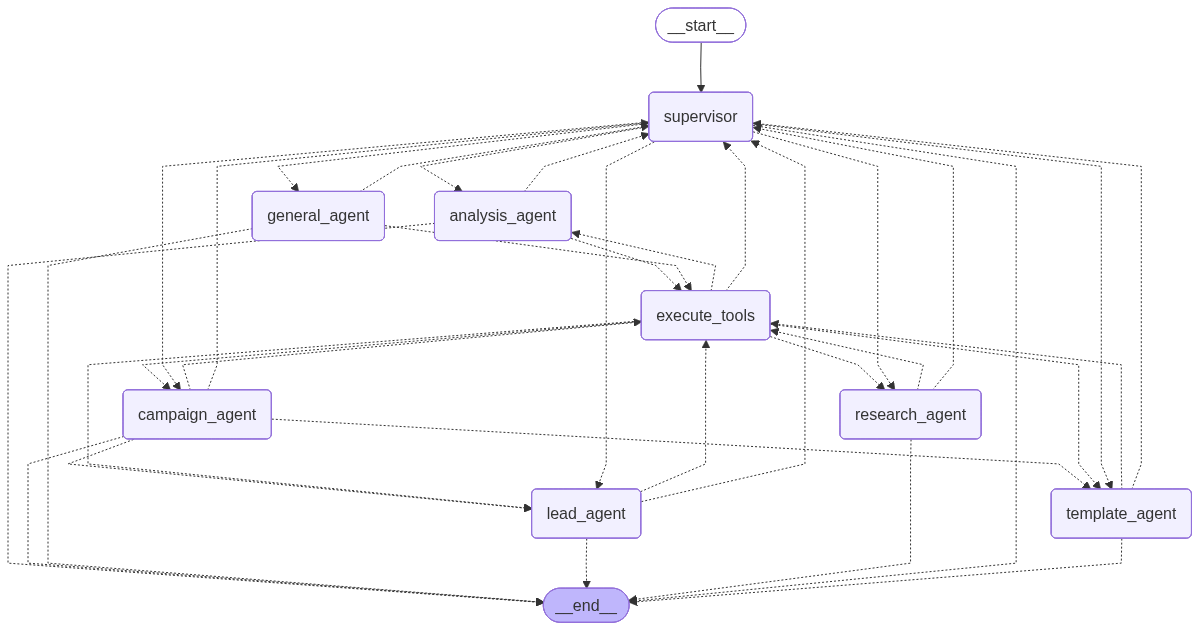

In [92]:
outreachx_final_mesh

In [ ]:
import time
import sys

def run_chat(agent_instance, thread_id: str = "outreachx_supervisor_102") -> None:
    config = {"configurable": {"thread_id": thread_id}}
    sys.stderr = sys.__stderr__
   
    print("=" * 60)
    print(f"🚀 OutreachX Multi-Agent Supervisor Mesh Live [HITL Enabled].")
    print(f"🔗 Active Thread ID: {thread_id}")
    print("=" * 60)
    print("Type 'exit' or 'quit' to close workspace context.\n")

    while True:
        try:
            # --- CHECK FOR ACTIVE HUMAN INTERRUPTS ---
            graph_state = agent_instance.get_state(config)
           
            if graph_state.next and "production_deployment" in graph_state.next:
                print("\n⚠️ [HUMAN INTERVENTION REQUIRED] ⚠️")
                print("The campaign queue is ready for launch, but requires your explicit authorization.")
                user_approval = input("👉 Type 'approve' to launch or 'fix' to modify: ").strip().lower()
               
                if user_approval in ["exit", "quit"]:
                    break
                   
                if user_approval == "approve":
                    print("\n🧠 Resuming graph with human approval signal...")
                    for event in agent_instance.stream(None, config, stream_mode="updates"):
                        pass
                else:
                    user_feedback = input("📝 Tell the agents what needs to be fixed or changed: ").strip()
                    inputs = {"messages": [("user", f"Human rejected launch. Feedback/Changes needed: {user_feedback}")]}
                    for event in agent_instance.stream(inputs, config, stream_mode="updates"):
                        pass
                continue

            # --- NORMAL CONVERSATION FLOW ---
            user_input = input("👤 You: ").strip()
            if not user_input:
                continue
            if user_input.lower() in ["exit", "quit"]:
                break

            inputs = {"messages": [("user", user_input)]}
            print("\n🧠 Supervisor orchestrating pipeline...", flush=True)

            # ============================
            # METRICS TRACKING
            # ============================
            start_time = time.time()
            first_event_time = None
            steps = 0
            tool_calls = 0
            active_node_history = []

            # Stream and measure runtime states
            for chunk in agent_instance.stream(inputs, config, stream_mode="updates"):
                steps += 1
                
                # Track Time To First Token (TTFT)
                if first_event_time is None:
                    first_event_time = time.time()

                # Count tool calls parameters
                for node_name, node_data in chunk.items():
                    if node_name not in ["supervisor", "execute_tools"]:
                        active_node_history.append(node_name)
                    
                    if isinstance(node_data, dict) and "messages" in node_data:
                        for msg in node_data["messages"]:
                            if hasattr(msg, "tool_calls") and msg.tool_calls:
                                tool_calls += len(msg.tool_calls)
                            elif hasattr(msg, "additional_kwargs") and msg.additional_kwargs.get("tool_calls"):
                                tool_calls += len(msg.additional_kwargs["tool_calls"])

            # Calculate metrics
            end_time = time.time()
            total_time = end_time - start_time
            ttft = (first_event_time - start_time) if first_event_time else 0.0

            # Get final unified execution state
            current_state = agent_instance.get_state(config)
            latest_messages = current_state.values.get("messages", [])

            # ===============================
            # RESPONSE DISPLAY FORMAT (FIXED)
            # ===============================
            if latest_messages:
                # Filter out raw tools objects to extract the last valid textual text message response
                text_messages = [m for m in latest_messages if hasattr(m, 'content') and m.content and m.type != "tool"]
                last_msg = text_messages[-1] if text_messages else latest_messages[-1]
                
                final_agent = active_node_history[-1] if active_node_history else "general_agent"
                
                # Dynamic Token Extraction
                input_tokens = output_tokens = total_tokens = "-"
                if hasattr(last_msg, "usage_metadata") and last_msg.usage_metadata:
                    usage = last_msg.usage_metadata
                    input_tokens = usage.get("input_tokens", "-")
                    output_tokens = usage.get("output_tokens", "-")
                    total_tokens = usage.get("total_tokens", "-")
                elif hasattr(last_msg, "response_metadata"):
                    usage = last_msg.response_metadata.get("token_usage") or last_msg.response_metadata.get("usage") or {}
                    input_tokens = usage.get("prompt_tokens", "-")
                    output_tokens = usage.get("completion_tokens", "-")
                    total_tokens = usage.get("total_tokens", "-")

                # Safe backup string conversion to keep printing stable if content isn't a clean string
                display_content = getattr(last_msg, "content", "")
                if not isinstance(display_content, str):
                    display_content = str(display_content)

                # Symmetrical Summary Logs output
                print("=" * 65)                
                print(f"✨ User Said: {user_input}")
                print("=" * 65)                
                print(f"\n🤖 [{final_agent.upper()} RESPONSE]:")
                print(display_content.strip())
                print("=" * 65)
                
                # ====================================================
                # 📊 LIVE GATEWAY FINANCIAL OBSERVABILITY METRICS
                # ====================================================
                # Pull cumulative token metrics and total session spend directly out of base_llm instance
                session_costs = base_llm.gateway_metrics.get("accumulated_cost_usd", 0.0)
                failed_routes = base_llm.gateway_metrics.get("failed_calls", 0)

                print(f"⏱️  Metrics      | Time: {total_time:.2f}s | TTFT: {ttft:.2f}s | Steps: {steps} | Tools: {tool_calls}")
                print(f"💰 Gateway Spend | Tokens -> In: {input_tokens} Out: {output_tokens} Total: {total_tokens} | Session Cost: ${session_costs:.6f} | API Failovers: {failed_routes}")
                print("=" * 65 + "\n")

        except Exception as e:
            print(f"\n❌ Mesh Execution Error Block: {e}\n")


In [94]:
if __name__ == "__main__":
    run_chat(outreachx_final_mesh)

🚀 OutreachX Multi-Agent Supervisor Mesh Live [HITL Enabled].
🔗 Active Thread ID: outreachx_supervisor_102
Type 'exit' or 'quit' to close workspace context.


🧠 Supervisor orchestrating pipeline...
⚠️ Groq unavailable. Trying next provider...
🔮 [Supervisor Decision]: Route selected -> [general_agent]
⚠️ Groq unavailable. Trying next provider...
✨ User Said: hi there

🤖 [GENERAL_AGENT RESPONSE]:
Hey Moksh! So good to see you! 👋 How's our favorite AIML Engineer doing today?
⏱️  Metrics | Time: 3.39s | TTFT: 2.22s | Steps: 2 | Tools: 0 | Tokens -> In: 231 Out: 69 Total: 300


🧠 Supervisor orchestrating pipeline...
⚠️ Groq unavailable. Trying next provider...
🔮 [Supervisor Decision]: Route selected -> [general_agent]
⚠️ Groq unavailable. Trying next provider...
✨ User Said: i think we have to work more in our skills

🤖 [GENERAL_AGENT RESPONSE]:
Totally get that feeling, Moksh! Always a good idea to sharpen those skills. 💪

Here at OutreachX, we're all about helping you level up your outreac